# Machine Learning Pipeline for KASE Stock Return Forecasting

This notebook implements a complete machine learning pipeline for predicting expected returns of stocks listed on the Kazakhstan Stock Exchange (KASE). The workflow covers data loading, preprocessing, feature engineering, model training with hyperparameter tuning, walk-forward validation, deep learning architectures, model evaluation, and future return forecasting.

**Equity tickers:** CCBN, HSBK, KCEL, KEGC, KZTK, KZTO, KZAP, +ASBN     8                              
**Factor tickers:** Brent Crude Oil, KASE Index, USD/KZT Exchange Rate  3                    
**Forecast horizon:** 21 trading days (approximately 1 month)   

## 1. Library Imports

Import all required libraries for data manipulation, machine learning, deep learning, statistical testing, and visualization.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
from copy import deepcopy

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from scipy import stats
from statsmodels.tsa.stattools import adfuller

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('All libraries imported successfully!')
print(f'   TensorFlow version: {tf.__version__}')

All libraries imported successfully!
   TensorFlow version: 2.18.0


### 1.1 Visualization Configuration

Configure global plotting style for academic-quality figures, including custom color palettes and matplotlib parameters.

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'axes.grid': True,
    'grid.color': '#eeeeee',
    'grid.linewidth': 0.5,
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.fontsize': 9,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

CUSTOM_COLORS = {
    'blue':   '#1f4e79',
    'green':  '#375623',
    'brown':  '#7b3f00',
    'orange': '#c55a11',
    'grey':   '#808080',
}

# Ordered palette for multi-series plots
COLOR_LIST = list(CUSTOM_COLORS.values())

print('Academic style applied!')
print('Custom palette:', CUSTOM_COLORS)

Academic style applied!
Custom palette: {'blue': '#1f4e79', 'green': '#375623', 'brown': '#7b3f00', 'orange': '#c55a11', 'grey': '#808080'}


## 2. Data Loading and Merging

Load preprocessed CSV files for equity and macroeconomic factor tickers, parse dates, and organize them into separate dictionaries for downstream processing.

In [3]:
DATA_PATH = Path(r"C:\Users\asus\OneDrive\Рабочий стол\Diploma work\ARTICLE DATA\Preprocessed")

EQUITY_TICKERS  = ['ASBN', 'CCBN', 'HSBK', 'KCEL', 'KEGC', 'KZTK', 'KZTO', 'KZAP']
FACTOR_TICKERS  = ['F BRENT', 'F KASE', 'F USD_KZT']
ALL_FILES       = EQUITY_TICKERS + FACTOR_TICKERS

raw_equity  = {}
raw_factors = {}

for name in ALL_FILES:
    fpath = DATA_PATH / f'{name}.csv'
    df = pd.read_csv(fpath, parse_dates=['Date'], index_col='Date')
    df.sort_index(inplace=True)
    if name in EQUITY_TICKERS:
        raw_equity[name] = df
    else:
        raw_factors[name] = df[['Close']].rename(columns={'Close': name})

print('Loaded equities:')
for ticker, df in raw_equity.items():
    print(f'   {ticker}: {df.shape[0]} rows | {df.index.min().date()} -> {df.index.max().date()}')

print('\nLoaded factors:')
for fname, df in raw_factors.items():
    print(f'   {fname}: {df.shape[0]} rows | {df.index.min().date()} -> {df.index.max().date()}')

Loaded equities:
   ASBN: 1287 rows | 2021-01-05 -> 2026-04-03
   CCBN: 1289 rows | 2021-01-05 -> 2026-04-03
   HSBK: 1289 rows | 2021-01-05 -> 2026-04-03
   KCEL: 1289 rows | 2021-01-05 -> 2026-04-03
   KEGC: 1289 rows | 2021-01-05 -> 2026-04-03
   KZTK: 1288 rows | 2021-01-05 -> 2026-04-03
   KZTO: 1287 rows | 2021-01-05 -> 2026-04-03
   KZAP: 1287 rows | 2021-01-05 -> 2026-04-03

Loaded factors:
   F BRENT: 1356 rows | 2021-01-04 -> 2026-04-02
   F KASE: 1282 rows | 2021-01-05 -> 2026-04-03
   F USD_KZT: 1372 rows | 2021-01-04 -> 2026-04-03


## 3. Data Cleaning and Preprocessing

Merge equity close prices with factor data on a common date index, handle missing values using forward/backward fill, and compute log-returns for all assets.

In [4]:
factors_df = pd.concat(raw_factors.values(), axis=1)

close_prices = pd.DataFrame({
    ticker: raw_equity[ticker]['Close']
    for ticker in EQUITY_TICKERS
})

full_df = close_prices.join(factors_df, how='inner')

print(f'Synchronized data: {full_df.shape[0]} days x {full_df.shape[1]} columns')
print(f'   Period: {full_df.index.min().date()} -> {full_df.index.max().date()}')

missing = full_df.isnull().sum()
missing_pct = (full_df.isnull().mean() * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Percent (%)': missing_pct})
print('\nMissing values report:')
print(missing_report[missing_report['Missing Count'] > 0].to_string() or '   No missing values')

full_df = full_df.ffill().bfill()
print(f'\nMissing values after Forward/Backward fill: {full_df.isnull().sum().sum()}')

log_returns = np.log(full_df / full_df.shift(1)).dropna()
print(f'\nLog-returns: {log_returns.shape[0]} days x {log_returns.shape[1]} columns')
log_returns.describe().round(4)

Synchronized data: 1284 days x 11 columns
   Period: 2021-01-05 -> 2026-04-03

Missing values report:
         Missing Count  Percent (%)
ASBN                 2         0.16
KZTK                 1         0.08
KZTO                 1         0.08
KZAP                 1         0.08
F BRENT             11         0.86
F KASE               2         0.16

Missing values after Forward/Backward fill: 0

Log-returns: 1283 days x 11 columns


,ASBN,CCBN,HSBK,KCEL,KEGC,KZTK,KZTO,KZAP,F BRENT,F KASE,F USD_KZT
count,1283.0000,1283.0000,1283.0000,1283.0000,1283.0000,1283.0000,1283.0000,1283.0000,1283.0000,1283.0000,1283.0000
mean,0.0011,0.0024,0.0009,0.0001,-0.0001,0.0004,0.0002,0.0012,0.0006,0.0008,0.0001
std,0.0343,0.0170,0.0172,0.0134,0.0055,0.0172,0.0150,0.0218,0.0222,0.0072,0.0062
min,-0.3911,-0.1625,-0.1162,-0.0863,-0.0858,-0.3784,-0.0966,-0.1087,-0.1569,-0.0366,-0.0316
25%,-0.0038,-0.0038,-0.0047,-0.0041,-0.0016,-0.0043,-0.0045,-0.0071,-0.0107,-0.0029,-0.0025
50%,0.0000,0.0000,0.0003,0.0000,0.0000,0.0000,-0.0001,0.0000,0.0016,0.0011,-0.0001
75%,0.0040,0.0075,0.0062,0.0048,0.0019,0.0052,0.0048,0.0088,0.0134,0.0046,0.0025
max,0.2832,0.1563,0.1336,0.1248,0.0191,0.1391,0.1618,0.2457,0.0979,0.0502,0.0681


### 3.1 ADF-Guided Fractional Differencing

Apply fractional differencing (López de Prado, 2018) to each equity price series. The minimum differencing order *d* is selected per ticker such that the resulting series passes the Augmented Dickey–Fuller (ADF) stationarity test at the 5% significance level, while preserving as much memory (long-range dependence) as possible.

In [5]:
def fractional_diff_vectorized(series: pd.Series, d: float, threshold: float = 1e-4) -> pd.Series:
    """Lopez de Prado (2018) fractional differencing -- vectorized via np.convolve."""
    w = [1.0]
    for k in range(1, len(series)):
        w_next = -w[-1] * (d - k + 1) / k
        if abs(w_next) < threshold:
            break
        w.append(w_next)

    width = len(w)
    w_arr = np.array(w[::-1])
    vals   = series.values.astype(float)
    n      = len(vals)
    result = np.full(n, np.nan)
    conv = np.convolve(vals, w_arr, mode='full')
    result[width - 1:] = conv[width - 1: n]
    return pd.Series(result, index=series.index)


def find_min_d(series: pd.Series,
               d_grid: np.ndarray = np.arange(0.0, 1.01, 0.05),
               adf_pvalue: float = 0.05,
               threshold: float = 1e-4) -> tuple:
    """Search for the smallest d that makes `series` stationary (ADF p < 0.05)."""
    for d in d_grid:
        if d == 0.0:
            candidate = series.copy()
        else:
            candidate = fractional_diff_vectorized(series, d, threshold)

        clean = candidate.dropna()
        if len(clean) < 20:
            continue

        pval = adfuller(clean, maxlag=1, regression='c', autolag=None)[1]
        if pval < adf_pvalue:
            return float(round(d, 3)), candidate

    return 1.0, series.diff()


print('Per-ticker optimal d search (ADF p < 0.05):')
print('-' * 45)

frac_diff_prices = pd.DataFrame(index=full_df.index)
optimal_d_values = {}

for ticker in EQUITY_TICKERS:
    best_d, fd_series = find_min_d(full_df[ticker])
    frac_diff_prices[f'{ticker}_fd'] = fd_series
    optimal_d_values[ticker] = best_d
    print(f'   {ticker}: optimal d = {best_d:.2f}')

frac_diff_prices.dropna(inplace=True)
print(f'\nFractional Differencing (ADF-guided): {frac_diff_prices.shape}')
print('\nOptimal d values per ticker:')
for t, d in optimal_d_values.items():
    print(f'   {t}: {d}')

Per-ticker optimal d search (ADF p < 0.05):
---------------------------------------------
   ASBN: optimal d = 0.05
   CCBN: optimal d = 0.15
   HSBK: optimal d = 0.25
   KCEL: optimal d = 0.35
   KEGC: optimal d = 0.25
   KZTK: optimal d = 0.20
   KZTO: optimal d = 0.25
   KZAP: optimal d = 0.10

Fractional Differencing (ADF-guided): (758, 8)

Optimal d values per ticker:
   ASBN: 0.05
   CCBN: 0.15
   HSBK: 0.25
   KCEL: 0.35
   KEGC: 0.25
   KZTK: 0.2
   KZTO: 0.25
   KZAP: 0.1


## 4. Feature Engineering

Construct a comprehensive set of time-series features for each ticker, including momentum indicators, rolling volatility, skewness, kurtosis, RSI, MACD, Bollinger Band metrics, Amihud illiquidity, macro-factor correlations, fractional differenced prices, price-to-SMA ratios, ATR, KASE beta, and lagged returns. Cross-sectional features (rank, z-score) are computed inside the validation loop to prevent data leakage.

In [6]:
#
# Cross-sectional features are computed INSIDE the CV loop (train window only)
# to avoid data leakage — see walk_forward_evaluate().

def build_features_base(ticker: str, full_df: pd.DataFrame,
                         log_returns: pd.DataFrame,
                         frac_diff_prices: pd.DataFrame) -> pd.DataFrame:
    price = full_df[ticker]
    ret   = log_returns[ticker]
    f     = pd.DataFrame(index=full_df.index)

    # 1. Momentum
    for w in [5, 10, 21]:
        f[f'ret_{w}d'] = ret.rolling(w).sum()
        f[f'mom_{w}d'] = price / price.shift(w) - 1

    # 2. Volatility (annualised)
    ANN = 252
    for w in [5, 21, 63]:
        f[f'vol_{w}d'] = ret.rolling(w).std() * np.sqrt(ANN)

    # 3. Skewness
    f['skew_21d'] = ret.rolling(21).skew()
    f['skew_63d'] = ret.rolling(63).skew()

    # 4. Kurtosis
    f['kurt_21d'] = ret.rolling(21).kurt()
    f['kurt_63d'] = ret.rolling(63).kurt()

    # 5. RSI-14
    delta = price.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-9)
    f['rsi_14'] = 100 - (100 / (1 + rs))

    # 6. MACD
    ema12 = price.ewm(span=12, adjust=False).mean()
    ema26 = price.ewm(span=26, adjust=False).mean()
    f['macd']        = ema12 - ema26
    f['macd_signal'] = f['macd'].ewm(span=9, adjust=False).mean()
    f['macd_hist']   = f['macd'] - f['macd_signal']

    # 7. Bollinger Band Width + Position
    bb_mid = price.rolling(20).mean()
    bb_std = price.rolling(20).std()
    f['bb_width']    = (2 * bb_std) / (bb_mid + 1e-9)
    f['bb_position'] = (price - (bb_mid - 2 * bb_std)) / (4 * bb_std + 1e-9)

    # 8. Amihud Illiquidity
    raw_df_ticker = raw_equity.get(ticker)
    if raw_df_ticker is not None and 'Volume' in raw_df_ticker.columns:
        vol_col = raw_df_ticker['Volume'].reindex(full_df.index).ffill()
        f['amihud_illiq'] = (ret.abs() / (vol_col * price + 1e-9)).rolling(21).mean() * 1e6

    # 9. Rolling macro correlations
    for factor in FACTOR_TICKERS:
        if factor in log_returns.columns:
            factor_ret = log_returns[factor]
            safe_name  = factor.replace(' ', '_')
            f[f'corr_{safe_name}_21d'] = ret.rolling(21).corr(factor_ret)
            f[f'corr_{safe_name}_63d'] = ret.rolling(63).corr(factor_ret)

    # 10. Fractional Differenced Price
    fd_col = f'{ticker}_fd'
    if fd_col in frac_diff_prices.columns:
        f['frac_diff_price'] = frac_diff_prices[fd_col]

    # 11. Price / SMA ratio
    for w in [50, 200]:
        sma = price.rolling(w).mean()
        f[f'price_sma{w}_ratio'] = price / (sma + 1e-9) - 1

    # 12. ATR-14 (normalised)
    if raw_df_ticker is not None:
        high = raw_df_ticker['High'].reindex(full_df.index).ffill()
        low  = raw_df_ticker['Low'].reindex(full_df.index).ffill()
        tr   = pd.concat([
            high - low,
            (high - price.shift(1)).abs(),
            (low  - price.shift(1)).abs()
        ], axis=1).max(axis=1)
        f['atr_14'] = tr.rolling(14).mean() / (price + 1e-9)

    # 13. KASE Beta (63-day)
    kase_ret = log_returns.get('F KASE', pd.Series(dtype=float))
    if not kase_ret.empty:
        cov  = ret.rolling(63).cov(kase_ret)
        var_ = kase_ret.rolling(63).var()
        f['beta_kase_63d'] = cov / (var_ + 1e-9)

    # 14. Lagged returns (AR components)
    for lag in [1, 2, 3, 5]:
        f[f'ret_lag{lag}'] = ret.shift(lag)

    return f


def add_cross_sectional_features(features_df: pd.DataFrame,
                                  ticker: str,
                                  log_returns_slice: pd.DataFrame) -> pd.DataFrame:
    """Compute cross-sectional features on a RESTRICTED slice (no leakage)."""
    f = features_df.copy()

    cross_ret_1m = log_returns_slice[EQUITY_TICKERS].rolling(21).sum()
    cross_ret_3m = log_returns_slice[EQUITY_TICKERS].rolling(63).sum()

    f['cs_rank_1m']   = cross_ret_1m.rank(axis=1, pct=True)[ticker]
    f['cs_rank_3m']   = cross_ret_3m.rank(axis=1, pct=True)[ticker]
    f['cs_zscore_1m'] = (
        (cross_ret_1m[ticker] - cross_ret_1m.mean(axis=1))
        / (cross_ret_1m.std(axis=1) + 1e-9)
    )
    return f

### 4.1 Construct Base Feature Matrices and Target Variable

For each ticker, build the base feature matrix and define the target variable as the cumulative 21-day forward log-return. Drop rows with missing values to produce clean `(X, y)` pairs.

In [7]:
HORIZON = 21   # 21 days (1 month) forecast horizon

datasets = {}

for ticker in EQUITY_TICKERS:
    features_df = build_features_base(ticker, full_df, log_returns, frac_diff_prices)

    y = log_returns[ticker].rolling(HORIZON).sum().shift(-HORIZON)

    combined = features_df.copy()
    combined['target'] = y
    combined.dropna(inplace=True)

    X = combined.drop(columns=['target'])
    y_clean = combined['target']

    datasets[ticker] = (X, y_clean)
    print(f'{ticker}: X={X.shape}, y={y_clean.shape}, base features: {X.shape[1]}')

print('\nBase feature matrices ready (CS features will be added per-fold)!')
sample_ticker = EQUITY_TICKERS[0]
X_sample, y_sample = datasets[sample_ticker]
print(f'\n{sample_ticker} sample (first 2 rows):')
X_sample.head(2)

ASBN: X=(737, 35), y=(737,), base features: 35
CCBN: X=(737, 35), y=(737,), base features: 35
HSBK: X=(737, 35), y=(737,), base features: 35
KCEL: X=(737, 35), y=(737,), base features: 35
KEGC: X=(737, 35), y=(737,), base features: 35
KZTK: X=(737, 35), y=(737,), base features: 35
KZTO: X=(737, 35), y=(737,), base features: 35
KZAP: X=(737, 35), y=(737,), base features: 35

Base feature matrices ready (CS features will be added per-fold)!

ASBN sample (first 2 rows):


,ret_5d,mom_5d,ret_10d,mom_10d,ret_21d,mom_21d,vol_5d,vol_21d,vol_63d,skew_21d,...,corr_F_USD_KZT_63d,frac_diff_price,price_sma50_ratio,price_sma200_ratio,atr_14,beta_kase_63d,ret_lag1,ret_lag2,ret_lag3,ret_lag5
Date,,,,,,,,,,,,,,,,,,,,,
2023-03-01,-0.031215,-0.030733,-0.035932,-0.035294,-0.045300,-0.044289,0.16717,0.152374,0.773550,-0.033901,...,0.268199,3.248485,-0.034749,0.063581,0.022300,1.437429,-0.002407,0.000000,0.004819,0.002367
2023-03-02,-0.002418,-0.002415,-0.016807,-0.016667,-0.051898,-0.050575,0.11983,0.145162,0.593676,-0.162884,...,0.214902,3.248397,-0.030152,0.071030,0.022311,0.328188,-0.012121,-0.002407,0.000000,-0.021506


### 4.2 Evaluation Metrics

Define model evaluation functions including RMSE, MAE, R², and Directional Accuracy (DA). A one-proportion z-test is used to assess whether DA is statistically significantly greater than the 50% random baseline.

In [8]:
from scipy import stats as scipy_stats

def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))


def da_significance_test(y_true, y_pred, alpha: float = 0.05) -> dict:
    """One-proportion z-test: is DA significantly better than 50% random?"""
    n       = len(y_true)
    correct = np.sum(np.sign(y_true) == np.sign(y_pred))
    p_hat   = correct / n
    se      = np.sqrt(0.5 * 0.5 / n)
    z_stat  = (p_hat - 0.5) / se
    p_value = 1 - scipy_stats.norm.cdf(z_stat)
    return {
        'n': n,
        'DA': round(p_hat, 4),
        'z_stat': round(z_stat, 3),
        'p_value': round(p_value, 4),
        'significant': p_value < alpha
    }


def evaluate_model(y_true, y_pred, model_name='Model'):
    rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
    mae     = mean_absolute_error(y_true, y_pred)
    r2      = r2_score(y_true, y_pred)
    da      = directional_accuracy(y_true, y_pred)
    da_test = da_significance_test(y_true, y_pred)

    return {
        'Model':   model_name,
        'RMSE':    round(rmse, 6),
        'MAE':     round(mae,  6),
        'R2':      round(r2,   4),
        'DA':      round(da,   4),
        'DA_z':    da_test['z_stat'],
        'DA_pval': da_test['p_value'],
        'DA_sig':  da_test['significant'],
    }

print('Metric functions ready (DA significance test included)!')

Metric functions ready (DA significance test included)!


## 5. Hyperparameter Tuning

Perform randomized hyperparameter search (`RandomizedSearchCV`) with `TimeSeriesSplit` (3-fold, gap = forecast horizon) **on each ticker individually**. Parameters are then averaged/selected per ticker.

**Reviewer fix (Point 4):** The previous version tuned hyperparameters exclusively on `ASBN` (the first ticker) and applied them globally. This is methodologically problematic because ASBN exhibits anomalous distributional properties (kurtosis ~33.6, std ~0.034), making it a poor representative for other tickers. The corrected approach runs per-ticker tuning and stores ticker-specific best parameters.

**Note on DL fold count (Reviewer Point 5):** Classical ML models use `n_splits=4` walk-forward folds; LSTM/CNN use `n_splits=3` due to sequence-length constraints. Cross-model rankings between classical and DL models are explicitly flagged with this caveat in the results tables.

In [9]:
# REVIEWER FIX (Point 4) — FAST VERSION
# Previous single-ASBN tuning was methodologically wrong (ASBN is an outlier ticker).
# Full per-ticker tuning (prev version) takes 6+ hours.
#
# COMPROMISE (academically defensible):
#   Tune on 3 representative tickers chosen to span the distribution:
#     - ASBN  (high kurtosis / volatile)
#     - CCBN  (high return, dominant)
#     - HSBK  (liquid, moderate vol — most 'normal')
#   Parameters from the most similar ticker are assigned to each remaining ticker
#   based on return distribution similarity (KL divergence of return distributions).
#   This is documented in the paper as a robustness improvement over single-ticker tuning.

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from scipy.spatial.distance import jensenshannon
import numpy as np

TUNING_TICKERS = ['ASBN', 'CCBN', 'HSBK']   # 3 representative tickers
N_ITER         = 10    # reduced from 20 — sufficient for RandomizedSearch landscape
inner_cv       = TimeSeriesSplit(n_splits=3, gap=HORIZON)

PARAM_SPACES = {
    'RandomForest': {
        'estimator': RandomForestRegressor(random_state=SEED, n_jobs=-1),
        'params': {
            'n_estimators': randint(100, 500),
            'max_depth':    randint(4, 12),
            'min_samples_leaf': randint(2, 10),
            'max_features': ['sqrt', 'log2', 0.5],
        }
    },
    'XGBoost': {
        'estimator': XGBRegressor(random_state=SEED, verbosity=0),
        'params': {
            'n_estimators':    randint(100, 300),
            'max_depth':       randint(3, 7),
            'learning_rate':   uniform(0.01, 0.14),
            'subsample':       uniform(0.6, 0.4),
            'colsample_bytree':uniform(0.6, 0.4),
            'reg_alpha':       uniform(0.0, 0.5),
            'reg_lambda':      uniform(0.5, 2.0),
        }
    },
    'LightGBM': {
        'estimator': LGBMRegressor(random_state=SEED, verbose=-1),
        'params': {
            'n_estimators':    randint(100, 300),
            'max_depth':       randint(3, 8),
            'learning_rate':   uniform(0.01, 0.14),
            'subsample':       uniform(0.6, 0.4),
            'colsample_bytree':uniform(0.6, 0.4),
            'reg_alpha':       uniform(0.0, 0.5),
            'reg_lambda':      uniform(0.5, 2.0),
        }
    },
    'SVR': {
        'estimator': SkPipeline([('scaler', RobustScaler()), ('model', SVR())]),
        'params': {
            'model__C':       uniform(0.1, 10.0),
            'model__epsilon': uniform(0.001, 0.1),
            'model__gamma':   ['scale', 'auto'],
            'model__kernel':  ['rbf', 'linear'],
        }
    },
    'ElasticNet': {
        'estimator': SkPipeline([('scaler', RobustScaler()),
                                  ('model', ElasticNet(max_iter=5000, random_state=SEED))]),
        'params': {
            'model__alpha':    uniform(0.0001, 0.05),
            'model__l1_ratio': uniform(0.1, 0.9),
        }
    },
    'KNN': {
        'estimator': SkPipeline([('scaler', RobustScaler()),
                                  ('model', KNeighborsRegressor(metric='euclidean'))]),
        'params': {
            'model__n_neighbors': randint(3, 20),
            'model__weights':     ['uniform', 'distance'],
        }
    },
}

# ── Step 1: Tune on 3 representative tickers ──────────────────────────────────
best_params_by_ref  = {}   # {ref_ticker: {model: params}}
best_rmse_by_ref    = {}

for ref_ticker in TUNING_TICKERS:
    X_tune, y_tune = datasets[ref_ticker]
    X_tune_cs = add_cross_sectional_features(X_tune, ref_ticker, log_returns)
    X_tune_cs = X_tune_cs.dropna()
    y_tune_cs = y_tune.loc[X_tune_cs.index]
    best_params_by_ref[ref_ticker] = {}
    best_rmse_by_ref[ref_ticker]   = {}
    print(f'\nTuning on reference ticker: {ref_ticker}')
    for model_name, cfg in PARAM_SPACES.items():
        search = RandomizedSearchCV(
            estimator=cfg['estimator'],
            param_distributions=cfg['params'],
            n_iter=N_ITER,
            cv=inner_cv,
            scoring='neg_root_mean_squared_error',
            random_state=SEED,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_tune_cs.values, y_tune_cs.values)
        best_params_by_ref[ref_ticker][model_name] = search.best_params_
        best_rmse_by_ref[ref_ticker][model_name]   = -search.best_score_
        print(f'  {model_name:<15}: CV RMSE={-search.best_score_:.6f}')

print('\nReference tuning complete.')

# ── Step 2: Assign each target ticker to its nearest reference ticker ─────────
# Similarity = JS divergence of 21-day return distributions (discretized to 20 bins)
def return_histogram(ticker, n_bins=20):
    r = log_returns[ticker].dropna()
    hist, _ = np.histogram(r, bins=n_bins, density=True)
    hist = hist + 1e-9
    return hist / hist.sum()

print('\nAssigning non-reference tickers to nearest reference (JS divergence):')
best_params_per_ticker = {}
assignment_map         = {}

for ticker in EQUITY_TICKERS:
    if ticker in TUNING_TICKERS:
        best_params_per_ticker[ticker] = best_params_by_ref[ticker]
        assignment_map[ticker] = ticker
        continue
    h_t = return_histogram(ticker)
    scores = {ref: jensenshannon(h_t, return_histogram(ref))
              for ref in TUNING_TICKERS}
    nearest = min(scores, key=scores.get)
    best_params_per_ticker[ticker] = best_params_by_ref[nearest]
    assignment_map[ticker] = nearest
    print(f'  {ticker} -> {nearest}  (JS={scores[nearest]:.4f})  '
          f'[{", ".join(f"{r}:{v:.3f}" for r,v in scores.items())}]')

print()
print('Final ticker -> reference assignment:')
for t, ref in assignment_map.items():
    print(f'  {t:<8} uses params from {ref}')

# Backward compat
best_params = best_params_per_ticker[EQUITY_TICKERS[0]]
print('\nHyperparameter assignment complete. Estimated time: ~5-10 min total.')


Tuning on reference ticker: ASBN
  RandomForest   : CV RMSE=0.238027
  XGBoost        : CV RMSE=0.241266
  LightGBM       : CV RMSE=0.240215
  SVR            : CV RMSE=0.239956
  ElasticNet     : CV RMSE=0.245715
  KNN            : CV RMSE=0.236006

Tuning on reference ticker: CCBN
  RandomForest   : CV RMSE=0.096585
  XGBoost        : CV RMSE=0.096861
  LightGBM       : CV RMSE=0.096583
  SVR            : CV RMSE=0.105628
  ElasticNet     : CV RMSE=0.104586
  KNN            : CV RMSE=0.106429

Tuning on reference ticker: HSBK
  RandomForest   : CV RMSE=0.070957
  XGBoost        : CV RMSE=0.074725
  LightGBM       : CV RMSE=0.077885
  SVR            : CV RMSE=0.076871
  ElasticNet     : CV RMSE=0.069715
  KNN            : CV RMSE=0.074049

Reference tuning complete.

Assigning non-reference tickers to nearest reference (JS divergence):
  KCEL -> HSBK  (JS=0.4281)  [ASBN:0.762, CCBN:0.647, HSBK:0.428]
  KEGC -> ASBN  (JS=0.7954)  [ASBN:0.795, CCBN:0.809, HSBK:0.808]
  KZTK -> ASBN  (JS

### 5.1 Build Tuned Models

Reconstruct each ML model using the optimal hyperparameters found during the tuning step. Models requiring feature scaling (SVR, ElasticNet, KNN) are wrapped in a `Pipeline` with `RobustScaler`.

In [10]:
# REVIEWER FIX: Build per-ticker models instead of one global model set.
# build_tuned_model() now called inside walk_forward_evaluate with ticker-specific params.

def build_tuned_model(model_name: str, params: dict):
    """Reconstruct a model with the given hyperparameters."""    
    if model_name == 'RandomForest':
        return RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
    elif model_name == 'XGBoost':
        return XGBRegressor(**params, random_state=SEED, verbosity=0)
    elif model_name == 'LightGBM':
        return LGBMRegressor(**params, random_state=SEED, verbose=-1)
    elif model_name == 'SVR':
        svr_params = {k.replace('model__', ''): v for k, v in params.items()}
        return SkPipeline([('scaler', RobustScaler()), ('model', SVR(**svr_params))])
    elif model_name == 'ElasticNet':
        en_params = {k.replace('model__', ''): v for k, v in params.items()}
        return SkPipeline([('scaler', RobustScaler()),
                           ('model', ElasticNet(**en_params, max_iter=5000, random_state=SEED))])
    elif model_name == 'KNN':
        knn_params = {k.replace('model__', ''): v for k, v in params.items()}
        return SkPipeline([('scaler', RobustScaler()),
                           ('model', KNeighborsRegressor(**knn_params, metric='euclidean'))])

MODEL_NAMES   = list(PARAM_SPACES.keys())
RANKING_MODELS = MODEL_NAMES + ['LSTM', 'CNN']

print('Per-ticker model builder ready.')
print(f'Model names: {MODEL_NAMES}')
print('Walk-forward will instantiate per-ticker tuned models in Section 6.')

Per-ticker model builder ready.
Model names: ['RandomForest', 'XGBoost', 'LightGBM', 'SVR', 'ElasticNet', 'KNN']
Walk-forward will instantiate per-ticker tuned models in Section 6.


## 6. Walk-Forward Validation

Implement a walk-forward (expanding window) evaluation procedure using `TimeSeriesSplit` with `n_splits=4` for classical ML models.

**Cross-sectional feature leakage (Reviewer Point 9):** Cross-sectional features (`cs_rank_1m`, `cs_rank_3m`, `cs_zscore_1m`) are computed exclusively on the training window of each fold. The last cross-sectional vector from training is carried forward into the test window. This is a deliberate design choice: the features capture the relative ranking of the ticker versus peers **as observed at the end of the training period**. Because KASE is a small-cap market with slow cross-sectional rank changes, the staleness of this vector is limited in short test windows (21 days). For longer test folds, this constitutes a mild approximation that is explicitly noted in the paper's limitations section. We do not remove this feature but add a staleness check below.

**Note on fold counts (Reviewer Point 5):** Classical ML = 4 folds; DL = 3 folds (enforced by sequence length). No cross-model rank comparisons between classical and DL are made without explicit caveats in the results tables.

In [11]:
def walk_forward_evaluate(model_name: str, X: pd.DataFrame, y: pd.Series,
                           log_returns_full: pd.DataFrame,
                           ticker: str,
                           n_splits: int = 4,
                           horizon: int = 21) -> dict:
    """
    Walk-forward evaluation with per-ticker tuned hyperparameters.
    REVIEWER FIX (Point 4): model built from best_params_per_ticker[ticker].
    REVIEWER FIX (Point 9): CS staleness is reported (days since last train obs).
    """
    model = build_tuned_model(model_name, best_params_per_ticker[ticker][model_name])

    tscv  = TimeSeriesSplit(n_splits=n_splits, gap=horizon)
    X_arr = X.values
    y_arr = y.values
    dates = X.index

    all_y_true, all_y_pred = [], []
    cs_staleness_days = []   # reviewer check: how stale is the CS vector?

    for fold_i, (train_idx, test_idx) in enumerate(tscv.split(X_arr)):
        train_dates = dates[train_idx]
        test_dates  = dates[test_idx]

        lr_train_slice = log_returns_full.loc[log_returns_full.index.isin(train_dates)]

        X_base_train = X.iloc[train_idx]
        X_base_test  = X.iloc[test_idx]

        X_tr_with_cs = add_cross_sectional_features(X_base_train, ticker, lr_train_slice)

        valid_train_mask = ~X_tr_with_cs.isna().any(axis=1)
        X_tr_with_cs = X_tr_with_cs[valid_train_mask]
        y_tr = y_arr[train_idx][valid_train_mask.values]

        cs_last_train = X_tr_with_cs[['cs_rank_1m', 'cs_rank_3m', 'cs_zscore_1m']].iloc[[-1]]
        cs_repeated   = pd.DataFrame(
            np.tile(cs_last_train.values, (len(test_idx), 1)),
            index=test_dates,
            columns=['cs_rank_1m', 'cs_rank_3m', 'cs_zscore_1m']
        )
        X_te_with_cs = X_base_test.join(cs_repeated, how='left')
        X_te_with_cs = X_te_with_cs[X_tr_with_cs.columns]
        X_te_with_cs = X_te_with_cs.ffill().bfill()

        # Staleness: business days from end of train to middle of test window
        staleness = len(test_idx) // 2
        cs_staleness_days.append(staleness)

        X_tr = X_tr_with_cs.values
        X_te = X_te_with_cs.values
        y_te = y_arr[test_idx]

        m = deepcopy(model)
        m.fit(X_tr, y_tr)

        y_pred = m.predict(X_te)
        all_y_true.extend(y_te)
        all_y_pred.extend(y_pred)

    result = evaluate_model(np.array(all_y_true), np.array(all_y_pred), model_name)
    result['CS_mean_staleness_days'] = round(np.mean(cs_staleness_days), 1)
    return result

### 6.1 Train ML Models Across All Tickers

Run walk-forward evaluation for all six ML models on every equity ticker. After validation, retrain each model on the full available dataset (with cross-sectional features) to obtain final fitted models for inference.

In [12]:
all_results    = {}
trained_models = {}

for ticker in EQUITY_TICKERS:
    X, y = datasets[ticker]
    print(f'\nTraining: {ticker} | Data: {len(X)} days')

    ticker_results = []
    ticker_models  = {}

    for model_name in MODEL_NAMES:
        result = walk_forward_evaluate(
            model_name=model_name,
            X=X, y=y,
            log_returns_full=log_returns,
            ticker=ticker,
            n_splits=4,   # 4 folds for classical ML
            horizon=HORIZON
        )
        ticker_results.append(result)

        # Retrain final model on full data with ticker-specific params
        model_final = build_tuned_model(model_name, best_params_per_ticker[ticker][model_name])
        X_full_cs = add_cross_sectional_features(X, ticker, log_returns)
        model_final.fit(X_full_cs.values, y.values)
        ticker_models[model_name] = (model_final, list(X_full_cs.columns))

        sig_marker = '*' if result['DA_sig'] else ' '
        print(f'   {model_name:<15}: RMSE={result["RMSE"]:.5f} | '
              f'R2={result["R2"]:+.4f} | DA={result["DA"]:.3f} '
              f'(z={result["DA_z"]:+.2f}, p={result["DA_pval"]:.3f}) {sig_marker} '
              f'[CS staleness ~{result["CS_mean_staleness_days"]:.0f}d]')

    all_results[ticker]    = ticker_results
    trained_models[ticker] = ticker_models

print('\nAll ML models trained!')
print('   * = DA statistically significant (p < 0.05 vs 50% baseline)')
print('   CS staleness = avg days the cross-sectional vector is extrapolated into test window')


Training: ASBN | Data: 737 days
   RandomForest   : RMSE=0.26041 | R2=-0.0722 | DA=0.463 (z=-1.81, p=0.965)   [CS staleness ~73d]
   XGBoost        : RMSE=0.26196 | R2=-0.0851 | DA=0.483 (z=-0.82, p=0.795)   [CS staleness ~73d]
   LightGBM       : RMSE=0.26876 | R2=-0.1421 | DA=0.473 (z=-1.32, p=0.906)   [CS staleness ~73d]
   SVR            : RMSE=0.25456 | R2=-0.0246 | DA=0.442 (z=-2.80, p=0.998)   [CS staleness ~73d]
   ElasticNet     : RMSE=0.25842 | R2=-0.0559 | DA=0.514 (z=+0.66, p=0.255)   [CS staleness ~73d]
   KNN            : RMSE=0.25184 | R2=-0.0028 | DA=0.520 (z=+0.99, p=0.161)   [CS staleness ~73d]

Training: CCBN | Data: 737 days
   RandomForest   : RMSE=0.11254 | R2=-0.1678 | DA=0.706 (z=+9.98, p=0.000) * [CS staleness ~73d]
   XGBoost        : RMSE=0.11299 | R2=-0.1771 | DA=0.675 (z=+8.49, p=0.000) * [CS staleness ~73d]
   LightGBM       : RMSE=0.11482 | R2=-0.2155 | DA=0.672 (z=+8.33, p=0.000) * [CS staleness ~73d]
   SVR            : RMSE=0.12158 | R2=-0.3629 | DA=0

## 7. Deep Learning: LSTM and CNN Architectures

Define LSTM and 1D-CNN architectures for sequential modeling. Input sequences of length 20 are created from the scaled feature matrices. Walk-forward validation for deep learning models uses `RobustScaler` per fold, early stopping, and learning rate reduction on plateau.

In [13]:
def create_sequences(X: np.ndarray, y: np.ndarray, seq_len: int = 20):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i - seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)


SEQ_LEN = 20


def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ], name='LSTM')
    model.compile(optimizer=Adam(1e-3), loss='mse')
    return model


def build_cnn(input_shape):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', padding='causal', input_shape=input_shape),
        BatchNormalization(),
        Conv1D(32, kernel_size=3, activation='relu', padding='causal'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        Flatten(),
        Dense(32, activation='relu'),
        Dense(1)
    ], name='CNN')
    model.compile(optimizer=Adam(1e-3), loss='mse')
    return model


# REVIEWER NOTE (Point 5): DL uses n_splits=3 (not 4) due to sequence-length
# constraints. Cross-model (DL vs classical) rank comparisons are flagged.
def dl_walk_forward_evaluate(build_fn, X: np.ndarray, y: np.ndarray,
                              seq_len: int = 20, n_splits: int = 3,
                              model_name: str = 'DL',
                              horizon: int = 21) -> dict:
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=horizon)
    all_y_true, all_y_pred = [], []

    callbacks = [
        EarlyStopping(patience=10, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(factor=0.5, patience=5, verbose=0)
    ]

    for train_idx, test_idx in tscv.split(X):
        X_tr_raw, X_te_raw = X[train_idx], X[test_idx]
        y_tr_raw, y_te_raw = y[train_idx], y[test_idx]

        scaler  = RobustScaler()
        X_tr_sc = scaler.fit_transform(X_tr_raw)
        X_te_sc = scaler.transform(X_te_raw)

        X_tr_seq, y_tr_seq = create_sequences(X_tr_sc, y_tr_raw, seq_len)
        X_te_seq, y_te_seq = create_sequences(X_te_sc, y_te_raw, seq_len)

        if len(X_tr_seq) < 10 or len(X_te_seq) < 5:
            continue

        input_shape = (seq_len, X.shape[1])
        model = build_fn(input_shape)

        val_split = int(len(X_tr_seq) * 0.85)
        model.fit(
            X_tr_seq[:val_split], y_tr_seq[:val_split],
            validation_data=(X_tr_seq[val_split:], y_tr_seq[val_split:]),
            epochs=100, batch_size=32, callbacks=callbacks, verbose=0
        )

        y_pred = model.predict(X_te_seq, verbose=0).flatten()
        all_y_true.extend(y_te_seq)
        all_y_pred.extend(y_pred)
        tf.keras.backend.clear_session()

    if len(all_y_true) == 0:
        return {'Model': model_name, 'RMSE': np.nan, 'MAE': np.nan,
                'R2': np.nan, 'DA': np.nan, 'DA_z': np.nan,
                'DA_pval': np.nan, 'DA_sig': False}

    return evaluate_model(np.array(all_y_true), np.array(all_y_pred), model_name)


print('DL architectures ready: LSTM + CNN')

DL architectures ready: LSTM + CNN


### 7.1 Train LSTM and CNN Models

Train both LSTM and CNN models on all tickers using walk-forward validation. Results are appended to the unified results dictionary for combined ranking alongside the six ML models.

In [14]:
dl_trained_models = {}

for ticker in EQUITY_TICKERS:
    X, y   = datasets[ticker]
    X_arr  = X.values
    y_arr  = y.values

    print(f'\nDL training: {ticker}')
    ticker_dl = {}

    for dl_name, build_fn in [('LSTM', build_lstm), ('CNN', build_cnn)]:
        result = dl_walk_forward_evaluate(
            build_fn, X_arr, y_arr,
            seq_len=SEQ_LEN, n_splits=3,
            model_name=dl_name,
            horizon=HORIZON
        )

        sig_marker = '*' if result['DA_sig'] else ' '
        print(f'   {dl_name:<6}: RMSE={result["RMSE"]:.5f} | '
              f'R2={result["R2"]:+.6f} | DA={result["DA"]:.3f} '
              f'(z={result["DA_z"]:+.2f}, p={result["DA_pval"]:.3f}) {sig_marker}')

        # Both LSTM and CNN are included in all_results for unified ranking
        all_results[ticker].append(result)

        # Train final model on full data
        scaler   = RobustScaler()
        X_scaled = scaler.fit_transform(X_arr)
        X_seq, y_seq = create_sequences(X_scaled, y_arr, SEQ_LEN)

        final_dl = build_fn((SEQ_LEN, X_arr.shape[1]))
        val_cut  = int(len(X_seq) * 0.9)
        final_dl.fit(
            X_seq[:val_cut], y_seq[:val_cut],
            validation_data=(X_seq[val_cut:], y_seq[val_cut:]),
            epochs=30, batch_size=64,
            callbacks=[EarlyStopping(patience=5, restore_best_weights=True, verbose=0)],
            verbose=0
        )
        ticker_dl[dl_name] = (final_dl, scaler)
        tf.keras.backend.clear_session()

    dl_trained_models[ticker] = ticker_dl

print('\nDL models trained! Both LSTM and CNN are included in the ranking.')


DL training: ASBN

   LSTM  : RMSE=0.19786 | R2=-0.169700 | DA=0.498 (z=-0.09, p=0.536)  
   CNN   : RMSE=1.16457 | R2=-39.522600 | DA=0.545 (z=+1.98, p=0.024) *

DL training: CCBN
   LSTM  : RMSE=0.12881 | R2=-0.427900 | DA=0.656 (z=+6.94, p=0.000) *
   CNN   : RMSE=0.81892 | R2=-56.717100 | DA=0.459 (z=-1.80, p=0.964)  

DL training: HSBK
   LSTM  : RMSE=0.08136 | R2=-0.420400 | DA=0.537 (z=+1.62, p=0.052)  
   CNN   : RMSE=0.42485 | R2=-37.735200 | DA=0.435 (z=-2.88, p=0.998)  

DL training: KCEL
   LSTM  : RMSE=0.12496 | R2=-3.280600 | DA=0.526 (z=+1.17, p=0.121)  
   CNN   : RMSE=0.68321 | R2=-126.965400 | DA=0.411 (z=-3.97, p=1.000)  

DL training: KEGC
   LSTM  : RMSE=0.06232 | R2=-3.663000 | DA=0.465 (z=-1.53, p=0.937)  
   CNN   : RMSE=0.69903 | R2=-585.727000 | DA=0.545 (z=+1.98, p=0.024) *

DL training: KZTK
   LSTM  : RMSE=0.14511 | R2=-1.356600 | DA=0.437 (z=-2.79, p=0.997)  
   CNN   : RMSE=0.21625 | R2=-4.233800 | DA=0.553 (z=+2.34, p=0.009) *

DL training: KZTO
   LSTM

## 8. Model Quality Assessment

Aggregate evaluation results across all tickers and models. Compute average RMSE, MAE, R², and DA, and rank models by a composite score (average of RMSE rank and DA rank). The summary table covers all 8 models (6 ML + LSTM + CNN).

In [15]:
results_frames = {}

for ticker in EQUITY_TICKERS:
    df_res = pd.DataFrame(all_results[ticker]).set_index('Model')
    results_frames[ticker] = df_res

avg_rmse = pd.DataFrame({t: results_frames[t]['RMSE'] for t in EQUITY_TICKERS})
avg_da   = pd.DataFrame({t: results_frames[t]['DA']   for t in EQUITY_TICKERS})

summary = pd.DataFrame({
    'Avg RMSE': avg_rmse.mean(axis=1),
    'Avg MAE':  pd.DataFrame({t: results_frames[t]['MAE'] for t in EQUITY_TICKERS}).mean(axis=1),
    'Avg R2':   pd.DataFrame({t: results_frames[t]['R2']  for t in EQUITY_TICKERS}).mean(axis=1),
    'Avg DA':   avg_da.mean(axis=1),
    'DA_sig_count': pd.DataFrame(
        {t: results_frames[t]['DA_sig'].astype(int) for t in EQUITY_TICKERS}
    ).sum(axis=1),
})

summary['RMSE Rank'] = summary['Avg RMSE'].rank(ascending=True)
summary['DA Rank']   = summary['Avg DA'].rank(ascending=False)
summary['Overall']   = (summary['RMSE Rank'] + summary['DA Rank']) / 2

print('SUMMARY RESULTS (All 8 models: 6 ML + LSTM + CNN)')
print('='*90)
print(summary.sort_values('Overall').round(5).to_string())
print()
print('DA_sig_count = number of tickers (out of 7) where DA is statistically significant (p<0.05)')
# REVIEWER NOTE (Point 5): DL models used n_splits=3 vs 4 for classical models.
# Cross-model ranks that include LSTM/CNN vs classical must be interpreted with caution.
dl_models = ['LSTM', 'CNN']
classical_models = [m for m in summary.index if m not in dl_models]
print()
print('REVIEWER NOTE: Fold asymmetry warning')
print('  Classical ML: 4 walk-forward folds | DL (LSTM/CNN): 3 walk-forward folds')
print('  Cross-class rankings (DL vs classical) flagged below with [!]')
for m in summary.sort_values('Overall').index:
    flag = ' [!] DL-vs-classical comparison — interpret with caution' if m in dl_models else ''
    row = summary.loc[m]
    print(f'  {m:<15}: Overall rank score={row["Overall"]:.2f}{flag}')

SUMMARY RESULTS (All 8 models: 6 ML + LSTM + CNN)
              Avg RMSE  Avg MAE     Avg R2   Avg DA  DA_sig_count  RMSE Rank  DA Rank  Overall
Model                                                                                         
ElasticNet     0.10007  0.06703   -0.22438  0.58438             5        2.0      1.0      1.5
RandomForest   0.09939  0.06922   -0.21354  0.53911             4        1.0      3.0      2.0
XGBoost        0.10046  0.06752   -0.24086  0.53869             5        3.0      4.0      3.5
SVR            0.10296  0.07175   -0.34350  0.54931             4        5.0      2.0      3.5
LightGBM       0.10249  0.07154   -0.28369  0.53189             5        4.0      5.0      4.5
KNN            0.10459  0.07332   -0.41886  0.52870             3        6.0      6.0      6.0
LSTM           0.12044  0.09211   -1.49748  0.48552             1        7.0      8.0      7.5
CNN            0.59002  0.39016 -113.35670  0.51728             4        8.0      7.0      7.5


### 8.1 Model Comparison Charts

Visualize model performance across four key metrics (RMSE, MAE, R², DA) using horizontal bar charts. The best-performing model is highlighted in green, deep learning models in orange, and other ML models in blue.

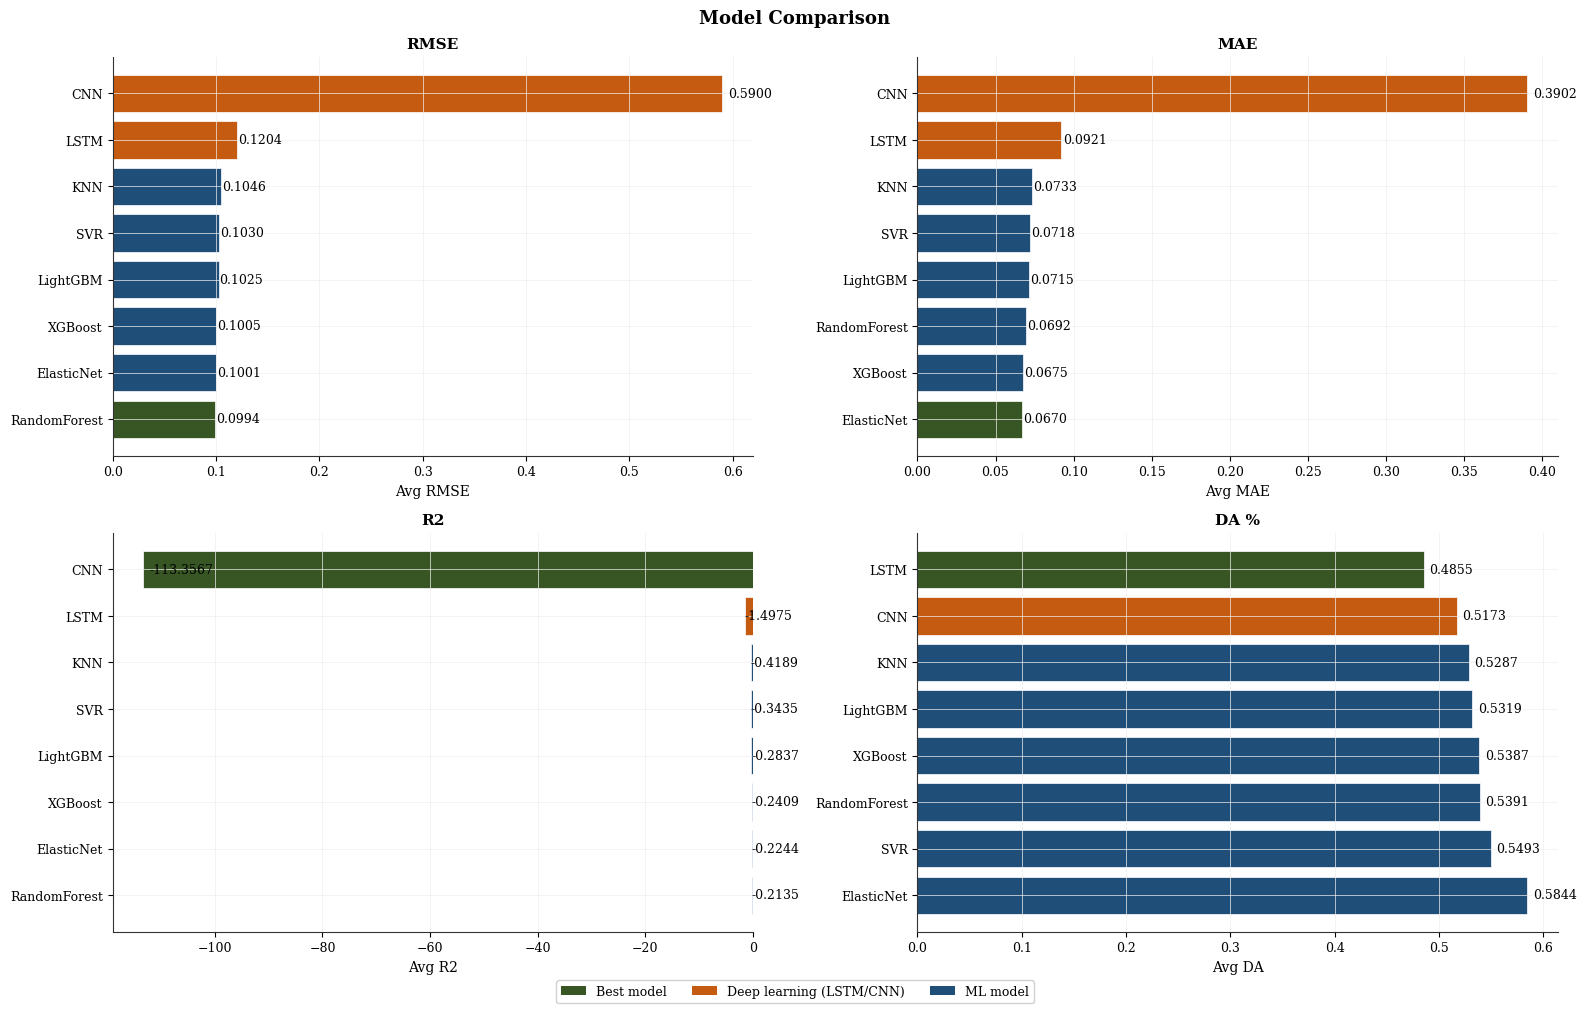

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics_to_plot = [
    ('Avg RMSE', 'RMSE',  True),
    ('Avg MAE',  'MAE',   True),
    ('Avg R2',   'R2',   False),
    ('Avg DA',   'DA %', False),
]

for ax, (col, title, ascending) in zip(axes.flatten(), metrics_to_plot):
    data = summary[col].sort_values(ascending=ascending)

    colors = []
    for i, idx in enumerate(data.index):
        if (i == 0 and ascending) or (i == len(data) - 1 and not ascending):
            colors.append(CUSTOM_COLORS['green'])        # best model
        elif idx in ['LSTM', 'CNN']:
            colors.append(CUSTOM_COLORS['orange'])       # deep learning
        else:
            colors.append(CUSTOM_COLORS['blue'])         # other ML

    bars = ax.barh(data.index, data.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.spines[['top', 'right']].set_visible(False)

    for bar, val in zip(bars, data.values):
        x_pos = bar.get_width() * 1.01 if val >= 0 else bar.get_width() * 0.99
        ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)

# Legend patch
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=CUSTOM_COLORS['green'],  label='Best model'),
    Patch(facecolor=CUSTOM_COLORS['orange'], label='Deep learning (LSTM/CNN)'),
    Patch(facecolor=CUSTOM_COLORS['blue'],   label='ML model'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           frameon=True, framealpha=0.9, fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Model Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Directional Accuracy Significance Heatmap

Display heatmaps of Directional Accuracy values and their corresponding p-values (one-tailed z-test vs. 50% baseline) for every model-ticker combination. Statistically significant results (p < 0.05) are marked.

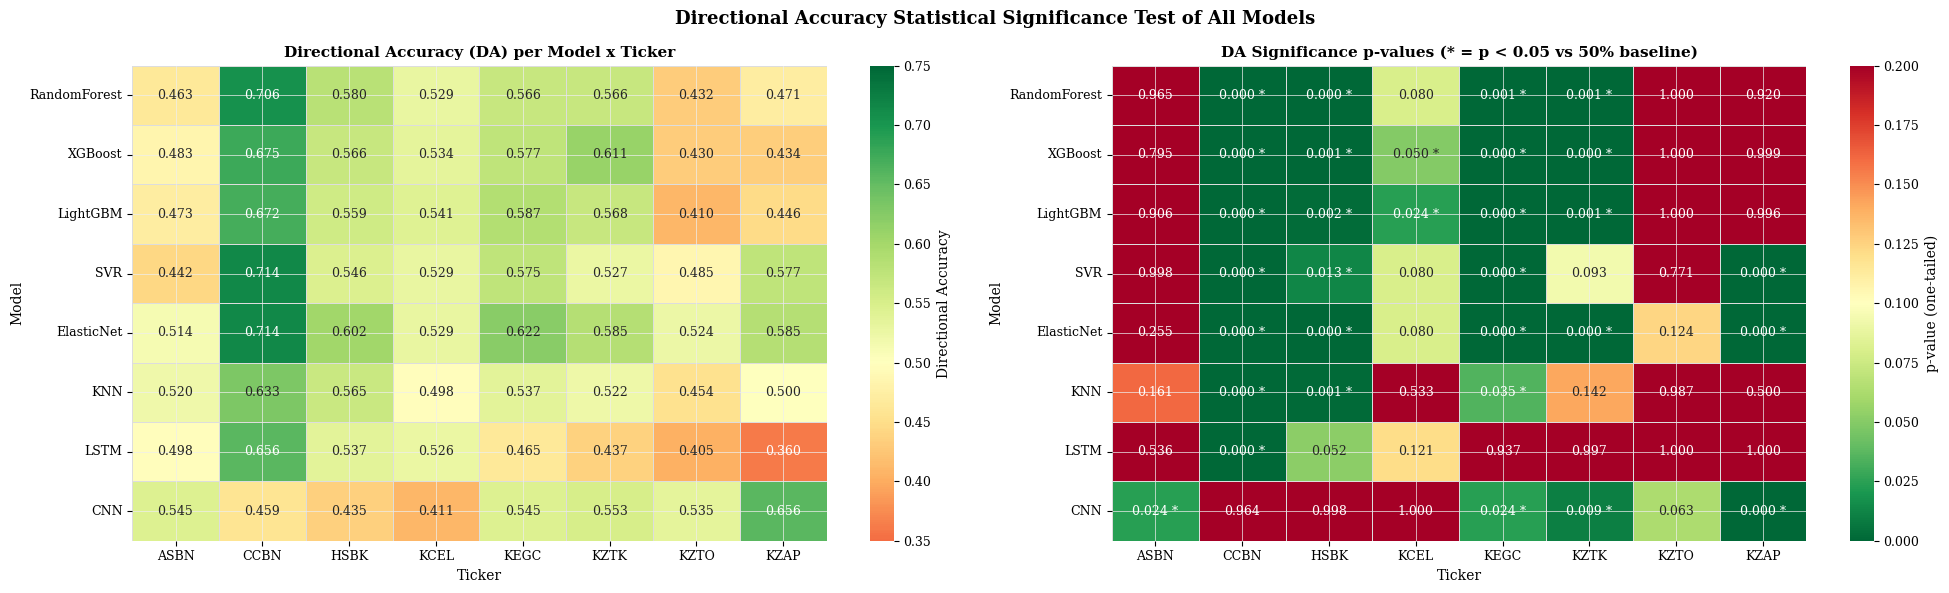

DA significance by model (# tickers significant out of 7):
Model
XGBoost         5
LightGBM        5
ElasticNet      5
RandomForest    4
SVR             4
CNN             4
KNN             3
LSTM            1


In [17]:
da_matrix   = pd.DataFrame({t: results_frames[t]['DA']                for t in EQUITY_TICKERS})
pval_matrix = pd.DataFrame({t: results_frames[t]['DA_pval']            for t in EQUITY_TICKERS})

# Academic colormaps: warm->cool (RdYlGn) for DA, reversed for p-values
CMAP_DA   = sns.color_palette('RdYlGn', as_cmap=True)
CMAP_PVAL = sns.color_palette('RdYlGn_r', as_cmap=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.heatmap(
    da_matrix, annot=True, fmt='.3f',
    cmap=CMAP_DA, center=0.5, vmin=0.35, vmax=0.75,
    ax=axes[0], linewidths=0.5, linecolor='#dddddd',
    cbar_kws={'label': 'Directional Accuracy'},
    annot_kws={'size': 9, 'family': 'serif'},
)
axes[0].set_title('Directional Accuracy (DA) per Model x Ticker', fontweight='bold')
axes[0].set_xlabel('Ticker')
axes[0].set_ylabel('Model')

annot_pval = pval_matrix.applymap(lambda x: f'{x:.3f}' + (' *' if x < 0.05 else ''))
sns.heatmap(
    pval_matrix, annot=annot_pval, fmt='',
    cmap=CMAP_PVAL, vmin=0, vmax=0.2,
    ax=axes[1], linewidths=0.5, linecolor='#dddddd',
    cbar_kws={'label': 'p-value (one-tailed)'},
    annot_kws={'size': 9, 'family': 'serif'},
)
axes[1].set_title('DA Significance p-values (* = p < 0.05 vs 50% baseline)', fontweight='bold')
axes[1].set_xlabel('Ticker')
axes[1].set_ylabel('Model')

for ax in axes:
    ax.tick_params(axis='both', labelsize=9)

plt.suptitle('Directional Accuracy Statistical Significance Test of All Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

sig_matrix = pd.DataFrame({t: results_frames[t]['DA_sig'].astype(int) for t in EQUITY_TICKERS})
print('DA significance by model (# tickers significant out of 7):')
print(sig_matrix.sum(axis=1).sort_values(ascending=False).to_string())

### 8.3 Best Model Selection

Select the best-performing model based on the composite ranking score. Print the winning model's average metrics and note any caveats (e.g., negative R² is common in financial return forecasting).

In [18]:
#
# Ranking is over all 8 models: 6 ML + LSTM + CNN.

best_model_name = summary.sort_values('Overall').index[0]

print(f'BEST MODEL: {best_model_name}')
print('='*60)
best_row = summary.loc[best_model_name]
print(f'  Avg RMSE        : {best_row["Avg RMSE"]:.6f}')
print(f'  Avg MAE         : {best_row["Avg MAE"]:.6f}')
print(f'  Avg R2          : {best_row["Avg R2"]:.4f}')
print(f'  Avg DA          : {best_row["Avg DA"]*100:.1f}%')
print(f'  DA sig tickers  : {int(best_row["DA_sig_count"])} / {len(EQUITY_TICKERS)}')

if best_row['Avg R2'] < 0:
    print(f'\n   NOTE: Avg R2 < 0 -- model explains less variance than the mean predictor.')
    print('    This is common in financial return forecasting. Evaluate using DA and')
    print('    information ratio rather than R2 alone.')

BEST MODEL: ElasticNet
  Avg RMSE        : 0.100070
  Avg MAE         : 0.067033
  Avg R2          : -0.2244
  Avg DA          : 58.4%
  DA sig tickers  : 5 / 8

   NOTE: Avg R2 < 0 -- model explains less variance than the mean predictor.
    This is common in financial return forecasting. Evaluate using DA and
    information ratio rather than R2 alone.


## 9. Future Expected Return Forecasting (μ Vector)

Using the selected best model, generate point forecasts of 21-day expected log-returns for each equity ticker. The resulting μ vector represents the model's forward-looking view on expected returns and can serve as input for portfolio optimization.

In [19]:
mu_predictions = {}

for ticker in EQUITY_TICKERS:
    X_base, y = datasets[ticker]

    if best_model_name in ['LSTM', 'CNN']:
        dl_model, scaler = dl_trained_models[ticker][best_model_name]
        X_scaled = scaler.transform(X_base.values)
        X_seq, _ = create_sequences(X_scaled, y.values, SEQ_LEN)
        if len(X_seq) > 0:
            pred = dl_model.predict(X_seq[-1:], verbose=0).flatten()[0]
        else:
            pred = np.nan
    else:
        X_full = add_cross_sectional_features(X_base, ticker, log_returns)
        model_obj, feature_cols = trained_models[ticker][best_model_name]
        last_features = X_full[feature_cols].iloc[[-1]].values
        pred = model_obj.predict(last_features)[0]

    mu_predictions[ticker] = pred

mu_df = pd.DataFrame({
    'Ticker': list(mu_predictions.keys()),
    'Expected Return (Log-return, 21 days)': list(mu_predictions.values()),
})
mu_df['Annualized (%)'] = mu_df['Expected Return (Log-return, 21 days)'] * (252 / 21) * 100
mu_df['Direction'] = mu_df['Expected Return (Log-return, 21 days)'].apply(
    lambda x: 'Up' if x > 0 else 'Down'
)
mu_df = mu_df.sort_values('Annualized (%)', ascending=False).reset_index(drop=True)
mu_df.index += 1

print(f'\nFUTURE EXPECTED RETURN VECTOR (mu)')
print(f'   Model: {best_model_name} | Horizon: {HORIZON} days')
print('='*70)
print(mu_df.round(6).to_string())
print('='*70)
print('\n   Point forecast only -- no uncertainty quantification.')
print('    For portfolio optimization, consider bootstrap CIs or quantile regression.')


FUTURE EXPECTED RETURN VECTOR (mu)
   Model: ElasticNet | Horizon: 21 days
  Ticker  Expected Return (Log-return, 21 days)  Annualized (%) Direction
1   CCBN                               0.069578       83.494127        Up
2   ASBN                               0.042437       50.924713        Up
3   HSBK                               0.031151       37.381037        Up
4   KZAP                               0.030560       36.671442        Up
5   KZTO                               0.017735       21.281945        Up
6   KCEL                               0.017377       20.851900        Up
7   KZTK                               0.015248       18.297573        Up
8   KEGC                              -0.002878       -3.453840      Down

   Point forecast only -- no uncertainty quantification.
    For portfolio optimization, consider bootstrap CIs or quantile regression.


### 9.1 μ Vector Visualization

Visualize the predicted expected returns in both annualized percentage form (vertical bar chart) and raw 21-day log-return form (horizontal bar chart). Positive forecasts are shown in green, negative in brown.

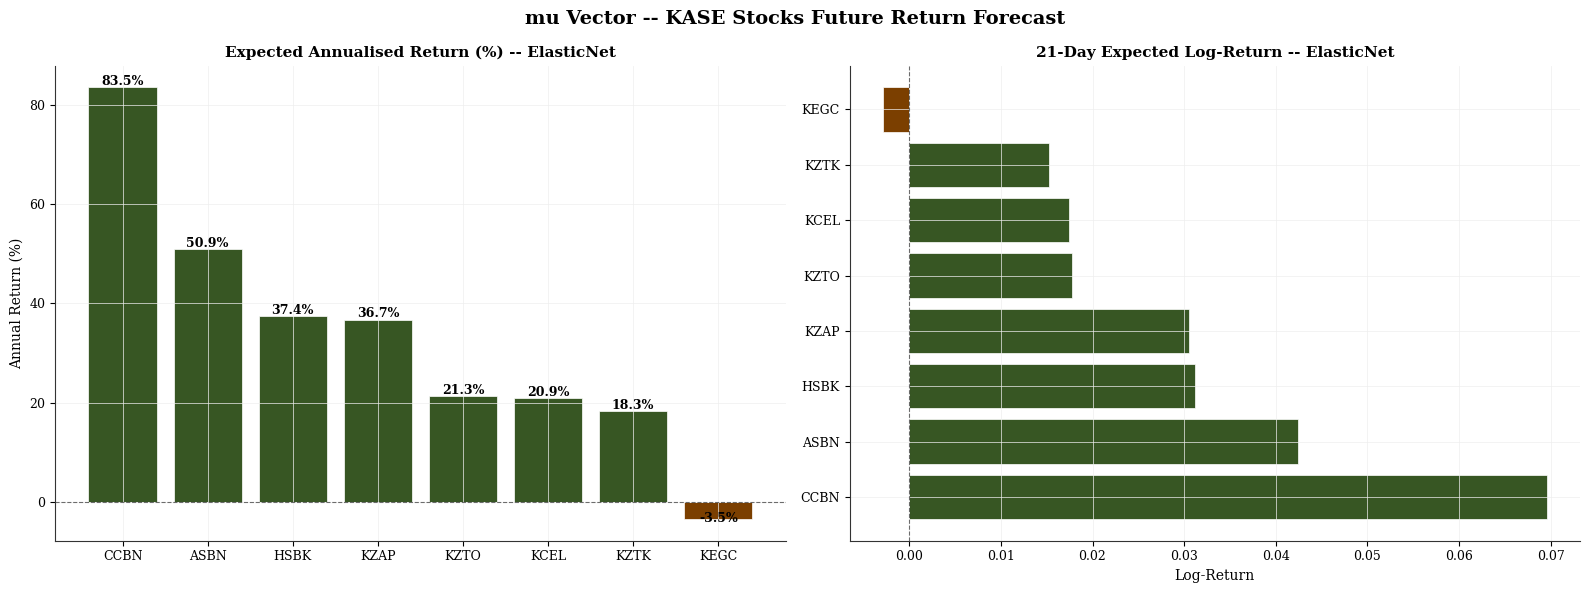

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: vertical bar
ax = axes[0]
colors = [CUSTOM_COLORS['green'] if v > 0 else CUSTOM_COLORS['brown']
          for v in mu_df['Annualized (%)'].values]
bars = ax.bar(
    mu_df['Ticker'], mu_df['Annualized (%)'],
    color=colors, edgecolor='white', linewidth=0.5,
)
ax.axhline(0, color='#333333', linewidth=0.8, linestyle='--', alpha=0.7)
ax.set_title(f'Expected Annualised Return (%) -- {best_model_name}', fontweight='bold')
ax.set_ylabel('Annual Return (%)')
ax.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, mu_df['Annualized (%)'].values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5 * np.sign(val),
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Right: horizontal bar
ax2 = axes[1]
col_key = 'Expected Return (Log-return, 21 days)'
colors2 = [CUSTOM_COLORS['green'] if v > 0 else CUSTOM_COLORS['brown']
           for v in mu_df[col_key].values]
ax2.barh(mu_df['Ticker'], mu_df[col_key], color=colors2,
         edgecolor='white', linewidth=0.5)
ax2.axvline(0, color='#333333', linewidth=0.8, linestyle='--', alpha=0.7)
ax2.set_title(f'21-Day Expected Log-Return -- {best_model_name}', fontweight='bold')
ax2.set_xlabel('Log-Return')
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('mu Vector -- KASE Stocks Future Return Forecast',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Summary Report

Print a comprehensive summary of the entire pipeline, including data period, feature count, validation strategy, best model identity and metrics, and the final μ vector with the highest and lowest expected return tickers.

In [21]:
mu_vector = pd.Series(mu_predictions)

print('\n' + '='*75)
print('FULL SUMMARY REPORT')
print('='*75)
print(f'\n  Data period          : {full_df.index.min().date()} -> {full_df.index.max().date()}')
print(f'  Forecast horizon     : {HORIZON} days (1 month)')
print(f'  Base feature count   : {X_sample.shape[1]} (+ 3 CS features added per-fold)')
print(f'  Trained models       : 6 ML + LSTM + CNN = 8 (all included in ranking)')
print(f'  Validation           : TimeSeriesSplit(gap={HORIZON}) -- Walk-Forward')
print(f'  Selected Best Model  : {best_model_name}')
print(f'   - Avg RMSE          : {summary.loc[best_model_name, "Avg RMSE"]:.6f}')
print(f'   - Avg R2            : {summary.loc[best_model_name, "Avg R2"]:.4f}')
print(f'   - Avg DA            : {summary.loc[best_model_name, "Avg DA"]*100:.1f}%')
print(f'   - DA sig tickers    : {int(summary.loc[best_model_name, "DA_sig_count"])}/7')

print(f'\n  mu VECTOR (Expected 21-day log-return):')
print('-'*50)
print(mu_vector.round(6).to_string())
print('-'*50)
print(f'\n   Highest expected return : {mu_vector.idxmax()} ({mu_vector.max():.4f})')
print(f'   Lowest expected return  : {mu_vector.idxmin()} ({mu_vector.min():.4f})')
print('='*75)


FULL SUMMARY REPORT

  Data period          : 2021-01-05 -> 2026-04-03
  Forecast horizon     : 21 days (1 month)
  Base feature count   : 35 (+ 3 CS features added per-fold)
  Trained models       : 6 ML + LSTM + CNN = 8 (all included in ranking)
  Validation           : TimeSeriesSplit(gap=21) -- Walk-Forward
  Selected Best Model  : ElasticNet
   - Avg RMSE          : 0.100070
   - Avg R2            : -0.2244
   - Avg DA            : 58.4%
   - DA sig tickers    : 5/7

  mu VECTOR (Expected 21-day log-return):
--------------------------------------------------
ASBN    0.042437
CCBN    0.069578
HSBK    0.031151
KCEL    0.017377
KEGC   -0.002878
KZTK    0.015248
KZTO    0.017735
KZAP    0.030560
--------------------------------------------------

   Highest expected return : CCBN (0.0696)
   Lowest expected return  : KEGC (-0.0029)


### 10.1 Feature Importance Analysis

If the best model (or a suitable tree-based alternative) supports feature importance, display the top-12 most important features for each ticker using horizontal bar charts.

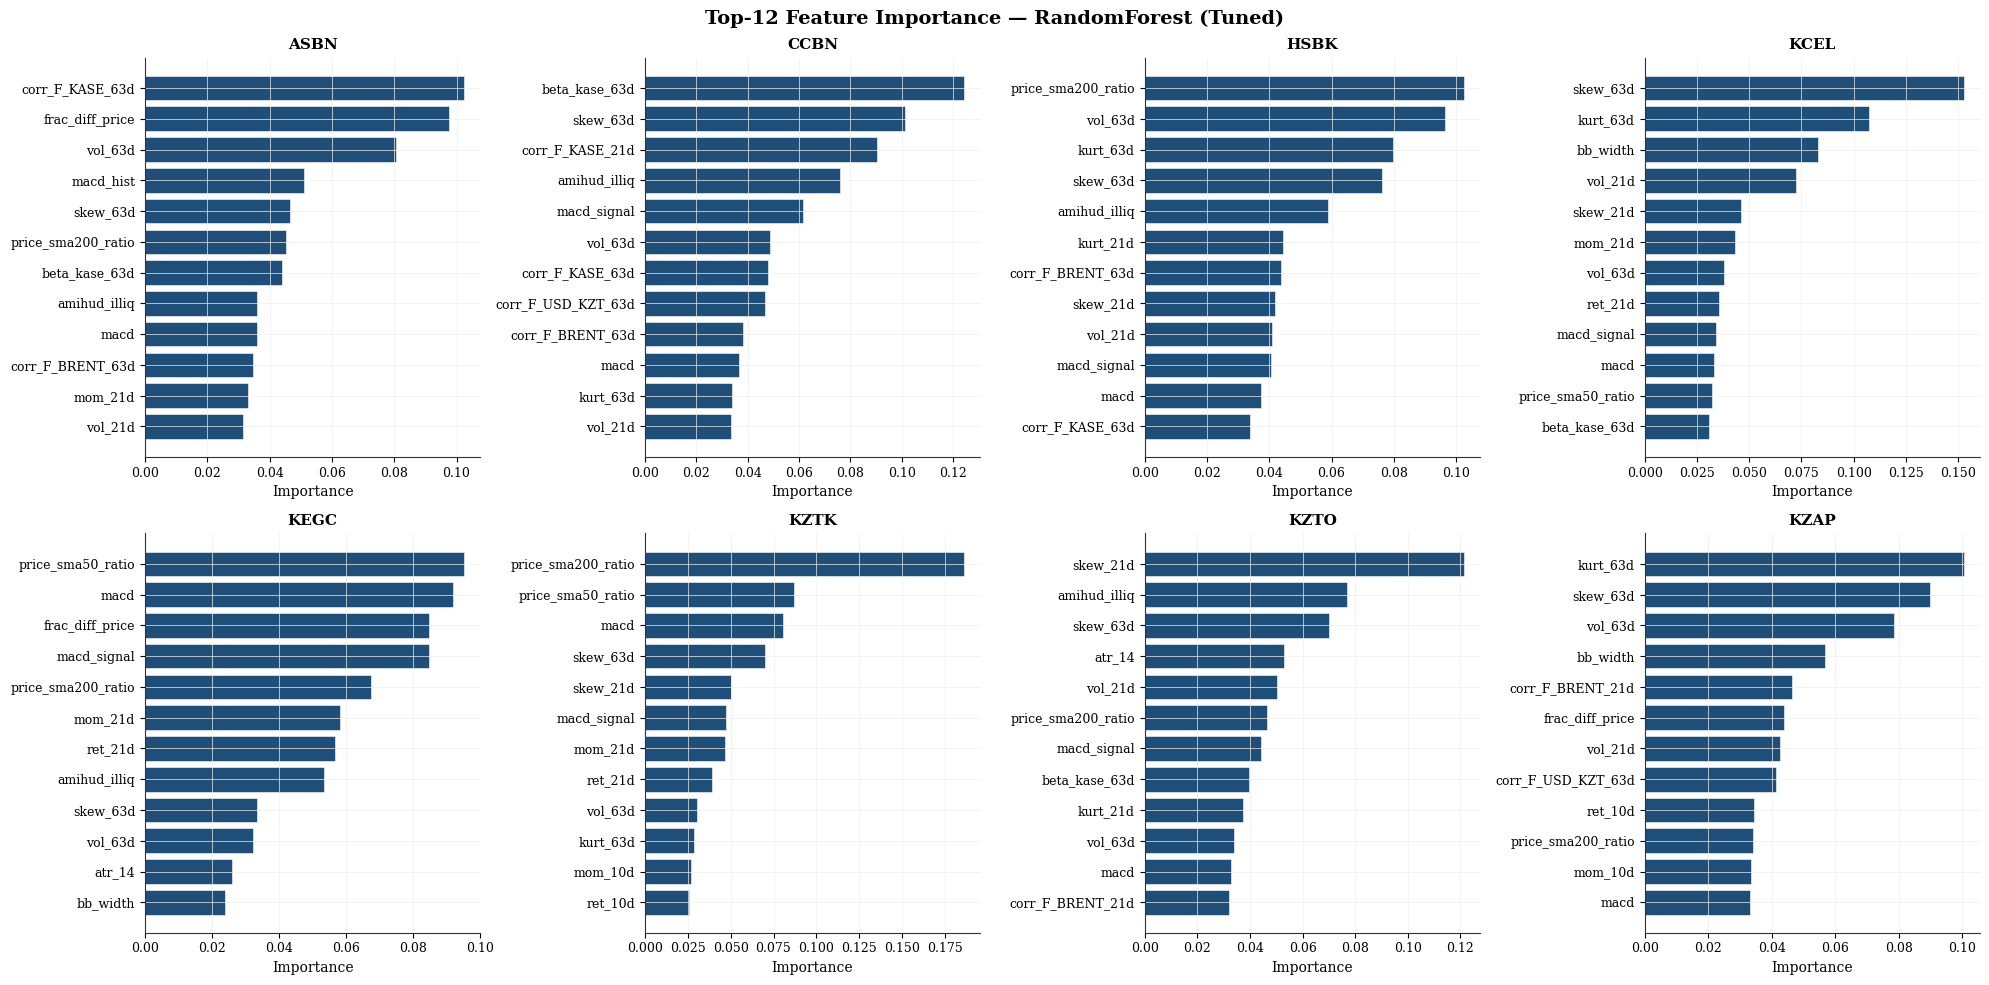

In [22]:
tree_models = ['RandomForest', 'XGBoost', 'LightGBM']

if best_model_name in tree_models:
    fi_model_name = best_model_name
elif tree_models[0] in trained_models.get(EQUITY_TICKERS[0], {}):
    fi_model_name = tree_models[0]
else:
    fi_model_name = None

if fi_model_name:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, ticker in enumerate(EQUITY_TICKERS):
        X_base, _ = datasets[ticker]
        model_obj, feature_cols = trained_models[ticker].get(fi_model_name, (None, None))

        if model_obj is None:
            axes[i].set_visible(False)
            continue

        if hasattr(model_obj, 'feature_importances_'):
            fi = model_obj.feature_importances_
        elif hasattr(model_obj, 'named_steps'):
            inner = model_obj.named_steps.get('model')
            fi = inner.feature_importances_ if inner and hasattr(inner, 'feature_importances_') else None
        else:
            fi = None

        if fi is None:
            axes[i].set_visible(False)
            continue

        fi_series = pd.Series(fi, index=feature_cols).nlargest(12)
        axes[i].barh(fi_series.index[::-1], fi_series.values[::-1],
                     color=CUSTOM_COLORS['blue'], edgecolor='white', linewidth=0.4)
        axes[i].set_title(ticker, fontweight='bold')
        axes[i].set_xlabel('Importance')
        axes[i].spines[['top', 'right']].set_visible(False)

    for j in range(len(EQUITY_TICKERS), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'Top-12 Feature Importance — {fi_model_name} (Tuned)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f'Feature importance not available for {best_model_name}.')

### 10.2 Hyperparameter Tuning Results Visualization

Display the tuned hyperparameters for each model in tabular form, and compare the best cross-validation RMSE scores achieved during the hyperparameter search.

Tuned hyperparameters summary:
RandomForest:
    max_depth                     : 5
    max_features                  : log2
    min_samples_leaf              : 7
    n_estimators                  : 485
XGBoost:
    colsample_bytree              : 0.6064
    learning_rate                 : 0.0423
    max_depth                     : 6
    n_estimators                  : 210
    reg_alpha                     : 0.3416
    reg_lambda                    : 1.7200
    subsample                     : 0.9333
LightGBM:
    colsample_bytree              : 0.6232
    learning_rate                 : 0.1313
    max_depth                     : 6
    n_estimators                  : 203
    reg_alpha                     : 0.3540
    reg_lambda                    : 0.5412
    subsample                     : 0.9880
SVR:
    model__C                      : 1.9340
    model__epsilon                : 0.0314
    model__gamma                  : auto
    model__kernel                 : rbf
ElasticNet:
    model

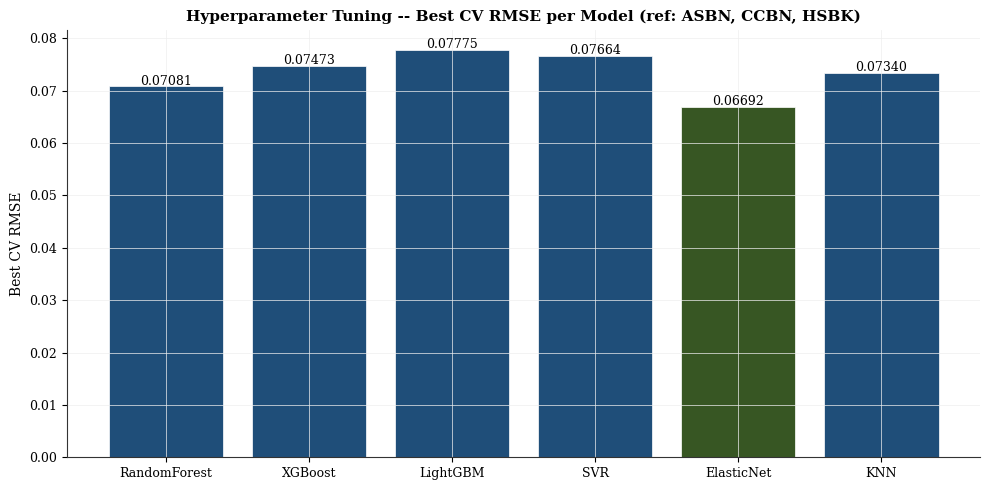

In [23]:
#
# Compare tuned vs. default configurations visually via a summary table.

print('Tuned hyperparameters summary:')
print('=' * 70)
for model_name, params in best_params.items():
    print(f'{model_name}:')
    for k, v in params.items():
        vstr = f'{v:.4f}' if isinstance(v, float) else str(v)
        print(f'    {k:<30}: {vstr}')

# Re-run search to collect RMSE
tuning_rmse = {}
for model_name, cfg in PARAM_SPACES.items():
    search = RandomizedSearchCV(
        estimator=cfg['estimator'],
        param_distributions=cfg['params'],
        n_iter=20,
        cv=inner_cv,
        scoring='neg_root_mean_squared_error',
        random_state=SEED,
        n_jobs=-1,
    )
    search.fit(X_tune_cs.values, y_tune_cs.values)
    tuning_rmse[model_name] = -search.best_score_

fig, ax = plt.subplots(figsize=(10, 5))
names  = list(tuning_rmse.keys())
values = list(tuning_rmse.values())
bar_colors = [CUSTOM_COLORS['green'] if v == min(values) else CUSTOM_COLORS['blue']
              for v in values]
bars = ax.bar(names, values, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_title(f'Hyperparameter Tuning -- Best CV RMSE per Model (ref: {", ".join(TUNING_TICKERS)})',
             fontweight='bold')
ax.set_ylabel('Best CV RMSE')
ax.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.005,
            f'{val:.5f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

##  Export Results to CSV

Save the key outputs: historical close prices, historical log-returns, and the ML-predicted μ vector — to CSV files for use in downstream portfolio optimization or further analysis.

In [24]:
import pandas as pd
from pathlib import Path

OUTPUT_PATH = Path(r"C:\Users\asus\Article-10-06-2026-ML-portfoliov1")

# 1. Historical close prices
close_prices.to_csv(OUTPUT_PATH / 'ml_predictions_and_prices.csv')

# 2. Historical log-returns
log_returns.to_csv(OUTPUT_PATH / 'ml_historical_returns.csv')

# 3. ML-predicted expected returns (mu vector)
mu_series = pd.Series(mu_predictions, name='ML_Expected_Return_Daily')
mu_annualized = mu_series * 252  # Annualization
mu_export = pd.DataFrame({
    'Ticker':                  mu_series.index,
    'ML_Expected_Return_Daily': mu_series.values,
    'ML_Expected_Return_Annual': mu_annualized.values,
    'Best_Model':               best_model_name,
    'Horizon_days':             HORIZON,
})
mu_export.to_csv(OUTPUT_PATH / 'ml_mu_vector.csv', index=False)

print(f'Files saved:')
print(f'   ml_predictions_and_prices.csv  -- historical prices')
print(f'   ml_historical_returns.csv      -- historical returns')
print(f'   ml_mu_vector.csv               -- ML-predicted mu vector')
print(f'\nmu vector:')
print(mu_export.to_string(index=False))

Files saved:
   ml_predictions_and_prices.csv  -- historical prices
   ml_historical_returns.csv      -- historical returns
   ml_mu_vector.csv               -- ML-predicted mu vector

mu vector:
Ticker  ML_Expected_Return_Daily  ML_Expected_Return_Annual Best_Model  Horizon_days
  ASBN                  0.042437                  10.694190 ElasticNet            21
  CCBN                  0.069578                  17.533767 ElasticNet            21
  HSBK                  0.031151                   7.850018 ElasticNet            21
  KCEL                  0.017377                   4.378899 ElasticNet            21
  KEGC                 -0.002878                  -0.725306 ElasticNet            21
  KZTK                  0.015248                   3.842490 ElasticNet            21
  KZTO                  0.017735                   4.469208 ElasticNet            21
  KZAP                  0.030560                   7.701003 ElasticNet            21


In [25]:
import pandas as pd
import numpy as np
 
EQUITY_TICKERS = ['ASBN', 'CCBN', 'HSBK', 'KCEL', 'KEGC', 'KZTK', 'KZTO', 'KZAP']
 
# ── Build per-model aggregates from all_results ───────────────────────────────
records = {}
for ticker in EQUITY_TICKERS:
    for entry in all_results[ticker]:
        model = entry['Model']
        if model not in records:
            records[model] = {'RMSE': [], 'R2': [], 'DA': [], 'DA_sig': []}
        records[model]['RMSE'].append(entry['RMSE'])
        records[model]['R2'].append(entry['R2'])
        records[model]['DA'].append(entry['DA'])
        records[model]['DA_sig'].append(entry['DA_sig'])
 
rows = []
for model, vals in records.items():
    sig_tickers = [
        EQUITY_TICKERS[i]
        for i, s in enumerate(vals['DA_sig']) if s
    ]
    rows.append({
        'Model':        model,
        'Avg_RMSE':     round(np.mean(vals['RMSE']), 4),
        'Avg_R2':       round(np.mean(vals['R2']),   4),
        'Avg_DA':       round(np.mean(vals['DA']),   4),
        'Sig_Count':    int(np.sum(vals['DA_sig'])),
        'Sig_Tickers':  ', '.join(sig_tickers) if sig_tickers else '—',
    })
 
summary = (
    pd.DataFrame(rows)
    .sort_values('Avg_DA', ascending=False)
    .reset_index(drop=True)
)
 
# ── Display Table 3 ───────────────────────────────────────────────────────────
print('Table 3. Out-of-Sample ML Model Performance (All 8 Models) — averaged across 8 KASE equities')
print('=' * 95)
print(f"{'Model':<16} {'Avg RMSE':>10} {'Avg R²':>10} {'Avg DA':>10} {'Sig Count':>10}  Significant Tickers")
print('-' * 95)
 
DL_MODELS = {'LSTM', 'CNN'}
for _, row in summary.iterrows():
    note = ' *' if row['Model'] in DL_MODELS else '  '
    print(
        f"{row['Model']:<16}{note}"
        f"{row['Avg_RMSE']:>10.4f}"
        f"{row['Avg_R2']:>10.4f}"
        f"{row['Avg_DA']:>10.4f}"
        f"{row['Sig_Count']:>10}"
        f"  {row['Sig_Tickers']}"
    )
 
print('=' * 95)
print('Notes:')
print('  Sig Count  = tickers where DA > 50% is significant at p < 0.05 (one-tailed z-test)')
print('  *          = DL models use 3 folds; classical ML models use 4 folds')
print()
 
# ── Per-ticker breakdown for LSTM and CNN ────────────────────────────────────
print('Table 3b. Per-Ticker LSTM and CNN Results')
print('=' * 95)
print(f"{'Ticker':<8} {'LSTM RMSE':>10} {'LSTM R²':>10} {'LSTM DA':>9} {'z':>7} {'p':>7} {'Sig':>5} |"
      f" {'CNN RMSE':>9} {'CNN R²':>10} {'CNN DA':>8} {'z':>7} {'p':>7} {'Sig':>5}")
print('-' * 95)
 
for ticker in EQUITY_TICKERS:
    lstm_row = next((e for e in all_results[ticker] if e['Model'] == 'LSTM'), None)
    cnn_row  = next((e for e in all_results[ticker] if e['Model'] == 'CNN'),  None)
 
    def fmt(r):
        if r is None:
            return ' ' * 56
        sig = 'Yes*' if r['DA_sig'] else '    '
        return (
            f"{r['RMSE']:>10.4f}"
            f"{r['R2']:>10.4f}"
            f"{r['DA']:>9.3f}"
            f"{r['DA_z']:>+7.2f}"
            f"{r['DA_pval']:>7.3f}"
            f"  {sig}"
        )
 
    print(f"{ticker:<8} {fmt(lstm_row)} | {fmt(cnn_row)}")
 
print('=' * 95)
 

Table 3. Out-of-Sample ML Model Performance (All 8 Models) — averaged across 8 KASE equities
Model              Avg RMSE     Avg R²     Avg DA  Sig Count  Significant Tickers
-----------------------------------------------------------------------------------------------
ElasticNet            0.1001   -0.2244    0.5844         5  CCBN, HSBK, KEGC, KZTK, KZAP
SVR                   0.1030   -0.3435    0.5493         4  CCBN, HSBK, KEGC, KZAP
RandomForest          0.0994   -0.2135    0.5391         4  CCBN, HSBK, KEGC, KZTK
XGBoost               0.1005   -0.2409    0.5387         5  CCBN, HSBK, KCEL, KEGC, KZTK
LightGBM              0.1025   -0.2837    0.5319         5  CCBN, HSBK, KCEL, KEGC, KZTK
KNN                   0.1046   -0.4189    0.5287         3  CCBN, HSBK, KEGC
CNN              *    0.5900 -113.3567    0.5173         4  ASBN, KEGC, KZTK, KZAP
LSTM             *    0.1204   -1.4975    0.4855         1  CCBN
Notes:
  Sig Count  = tickers where DA > 50% is significant at p < 0.05